In [2]:
import torch
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
from torch import nn

from tqdm.notebook import tqdm
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

Using cuda device


In [10]:
def LV_grad(_, v, params):
    x, y = v
    alpha, beta, gamma, delta = params
    return np.array([x * (alpha - beta * y), y * (delta * x - gamma)])

def LV_jac(_, v, params):
    x, y = v
    alpha, beta, gamma, delta = params
    return np.array([[alpha - beta * y, -beta * x], [delta * y, delta * x - gamma]])

In [32]:
params = np.array([0.6, 0.025, 0.5, 0.0125])
t0 = 0
tf = 90
ts = np.arange(t0, tf + 1)
v0 = np.array([30, 4])

In [35]:
LV_sol = solve_ivp(LV_grad, (t0, tf), v0, t_eval = ts, jac = LV_jac, args = (params,), method = "Radau", dense_output = True)

In [88]:
train_X = torch.from_numpy(LV_sol.t).unsqueeze(-1).float().to(device)
train_y = torch.from_numpy(LV_sol.y.T).float().to(device)

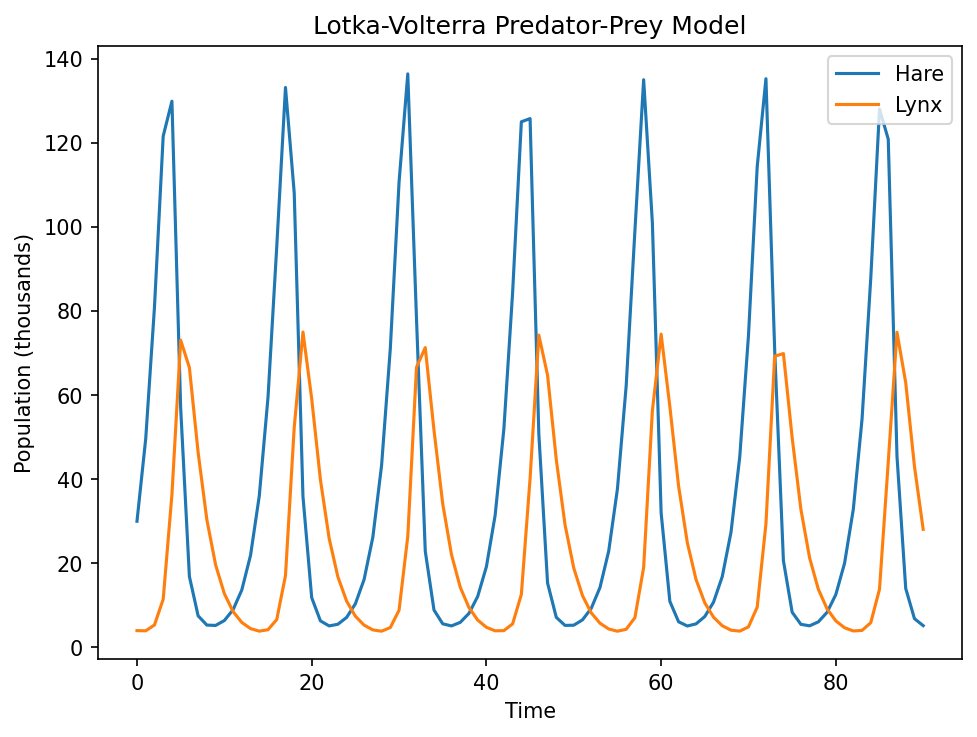

In [89]:
plt.figure(dpi = 150, layout = "constrained")
plt.plot(LV_sol.t, LV_sol.y[0], label = "Hare")
plt.plot(LV_sol.t, LV_sol.y[1], label = "Lynx")
plt.xlabel("Time")
plt.ylabel("Population (thousands)")
plt.title("Lotka-Volterra Predator-Prey Model")
plt.legend()
plt.show()

In [136]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.linear_relu_stack(x)

In [137]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [138]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [139]:
def train(model, loss_fn, optimizer):
    model.train()

    # Compute prediction error
    pred = model(train_X)
    loss = loss_fn(pred, train_y)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [140]:
def test(model, loss_fn):
    model.eval()
    with torch.no_grad():
        pred = model(train_X)
        loss = loss_fn(pred, train_y).item()
    print(f"Training loss: {loss:>8f} \n")

In [141]:
epochs = 10000
for t in tqdm(range(epochs)):
    train(model, loss_fn, optimizer)
    if t % 2500 == 0:
        print(f"Epoch {t}")
        test(model, loss_fn)

  0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 0
Training loss: 2123.378418 

Epoch 2500
Training loss: 1008.111145 

Epoch 5000
Training loss: 915.612122 

Epoch 7500
Training loss: 835.302063 



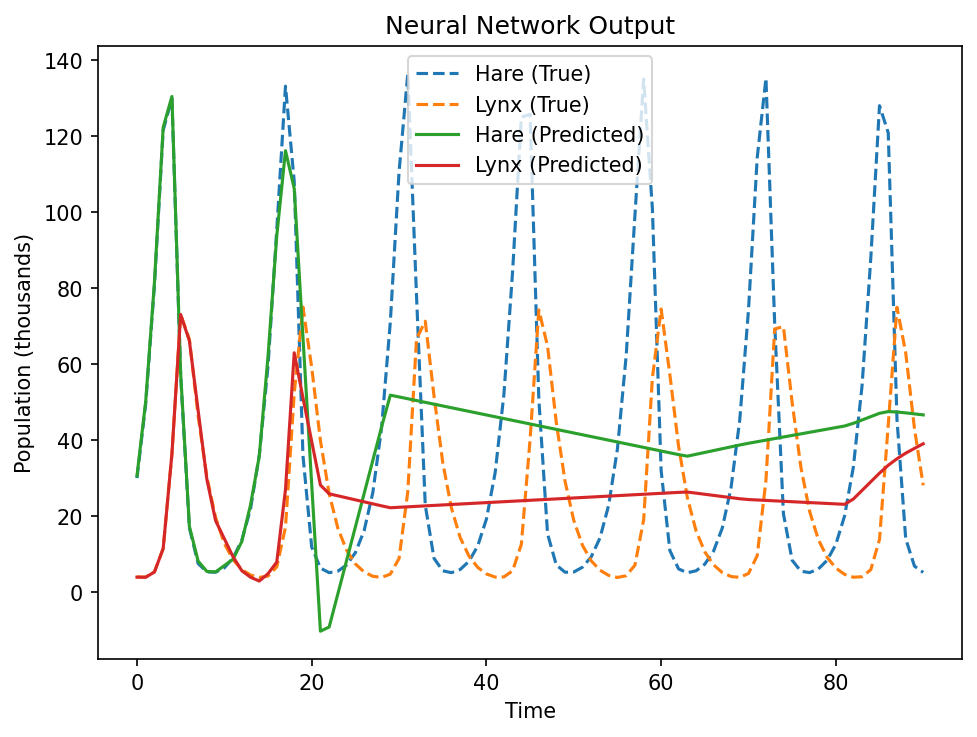

In [142]:
v_pred = model(train_X).detach().cpu().numpy().T
plt.figure(dpi = 150, layout = "constrained")
plt.plot(LV_sol.t, LV_sol.y[0], label = "Hare (True)", linestyle = "--")
plt.plot(LV_sol.t, LV_sol.y[1], label = "Lynx (True)", linestyle = "--")
plt.plot(LV_sol.t, v_pred[0], label = "Hare (Predicted)")
plt.plot(LV_sol.t, v_pred[1], label = "Lynx (Predicted)")
plt.xlabel("Time")
plt.ylabel("Population (thousands)")
plt.title("Neural Network Output")
plt.legend()
plt.show()